<a href="https://colab.research.google.com/github/Kalana-Lakshan/ML-Self-Learning/blob/main/ML_practice_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from xgboost import XGBRegressor


In [28]:
train_data = pd.read_csv('/content/drive/MyDrive/Lab 2 Regression/train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Lab 2 Regression/test.csv')
sample_sub_data = pd.read_csv('/content/drive/MyDrive/Lab 2 Regression/sample_submission.csv')

In [29]:
train_data.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.0201,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,...,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.3340,Solitude,6.0,0.715,46874.0,15.0,...,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.1110,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,...,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.1960,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,...,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.0811,Afraid,6.0,0.856,215346.0,5.0,...,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78


In [30]:
train_data.shape

(61609, 62)

In [31]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61609 entries, 0 to 61608
Data columns (total 62 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          61609 non-null  int64  
 1   emotional_charge_2          59167 non-null  float64
 2   groove_efficiency_1         61429 non-null  float64
 3   beat_frequency_1            61223 non-null  float64
 4   organic_texture_2           61226 non-null  float64
 5   composition_label_0         58660 non-null  object 
 6   harmonic_scale_1            58304 non-null  float64
 7   intensity_index_0           55638 non-null  float64
 8   duration_ms_0               60320 non-null  float64
 9   album_name_length           52015 non-null  float64
 10  beat_frequency_0            51878 non-null  float64
 11  beat_frequency_2            59843 non-null  float64
 12  artist_count                58348 non-null  float64
 13  composition_label_1         601

In [32]:
train_data.isnull().sum()

,0
id,0
emotional_charge_2,2442
groove_efficiency_1,180
beat_frequency_1,386
organic_texture_2,383
...,...
emotional_resonance_0,1546
harmonic_scale_2,4467
intensity_index_2,693
instrumental_density_0,709


<Axes: >

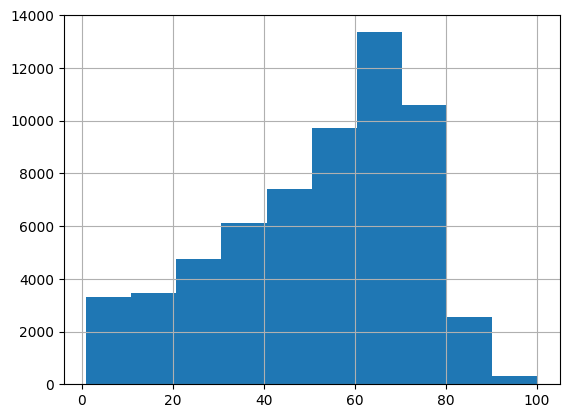

In [33]:
train_data['target'].hist()

In [34]:
train_data['publication_timestamp']

,publication_timestamp
0,2021-06-04
1,2019-07-01
2,2014-11-18
3,2015-09-25
4,2006-01-01
...,...
61604,2020-02-21
61605,2019-08-23
61606,2021-07-11
61607,2019-12-13


In [35]:
#seperating publication_timestamp into year,month,day
train_data['publication_timestamp'] = pd.to_datetime(train_data['publication_timestamp'],errors='coerce')
test_data['publication_timestamp'] = pd.to_datetime(test_data['publication_timestamp'],errors='coerce')

train_data['year'] = train_data['publication_timestamp'].dt.year
train_data['month'] = train_data['publication_timestamp'].dt.month
train_data['day'] = train_data['publication_timestamp'].dt.day

test_data['year'] = test_data['publication_timestamp'].dt.year
test_data['month'] = test_data['publication_timestamp'].dt.month
test_data['day'] = test_data['publication_timestamp'].dt.day

train_data.drop('publication_timestamp',axis = 1,inplace = True)
test_data.drop('publication_timestamp',axis = 1,inplace = True)

In [36]:
num_cols = train_data.select_dtypes(include = np.number).columns
cat_cols = train_data.select_dtypes(include = 'object').columns

In [37]:
len(num_cols) + len(cat_cols) == len(train_data.columns)

True

In [ ]:
#missing values handling
train_data[num_cols] = train_data[num_cols].fillna(train_data[num_cols].median())
train_data[cat_cols] = train_data[cat_cols].fillna(train_data[num_cols].mode()[0]).astype(str)

test_data[num_cols] = test_data[num_cols].fillna(train_data[num_cols].median())
test_data[cat_cols] = test_data[cat_cols].fillna(train_data[num_cols].mode()).astype(str)

<Axes: >

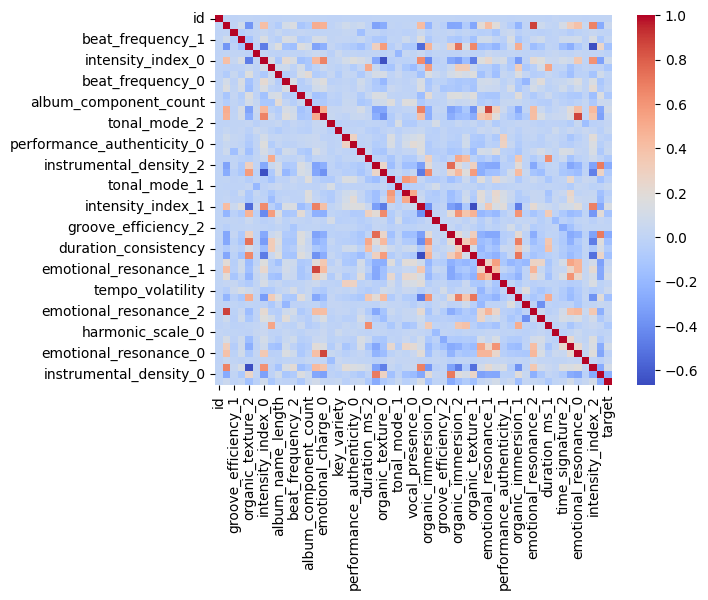

In [ ]:


sns.heatmap(train_data[num_cols].corr(),cmap = "coolwarm")

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'emotional_charge_2'}>,
        <Axes: title={'center': 'groove_efficiency_1'}>,
        <Axes: title={'center': 'beat_frequency_1'}>,
        <Axes: title={'center': 'organic_texture_2'}>,
        <Axes: title={'center': 'harmonic_scale_1'}>,
        <Axes: title={'center': 'intensity_index_0'}>],
       [<Axes: title={'center': 'duration_ms_0'}>,
        <Axes: title={'center': 'album_name_length'}>,
        <Axes: title={'center': 'beat_frequency_0'}>,
        <Axes: title={'center': 'beat_frequency_2'}>,
        <Axes: title={'center': 'artist_count'}>,
        <Axes: title={'center': 'album_component_count'}>,
        <Axes: title={'center': 'emotional_charge_1'}>],
       [<Axes: title={'center': 'emotional_charge_0'}>,
        <Axes: title={'center': 'tonal_mode_2'}>,
        <Axes: title={'center': 'key_variety'}>,
        <Axes: title={'center': 'performance_authenticity_2'}>,
        <Axes: title={'center

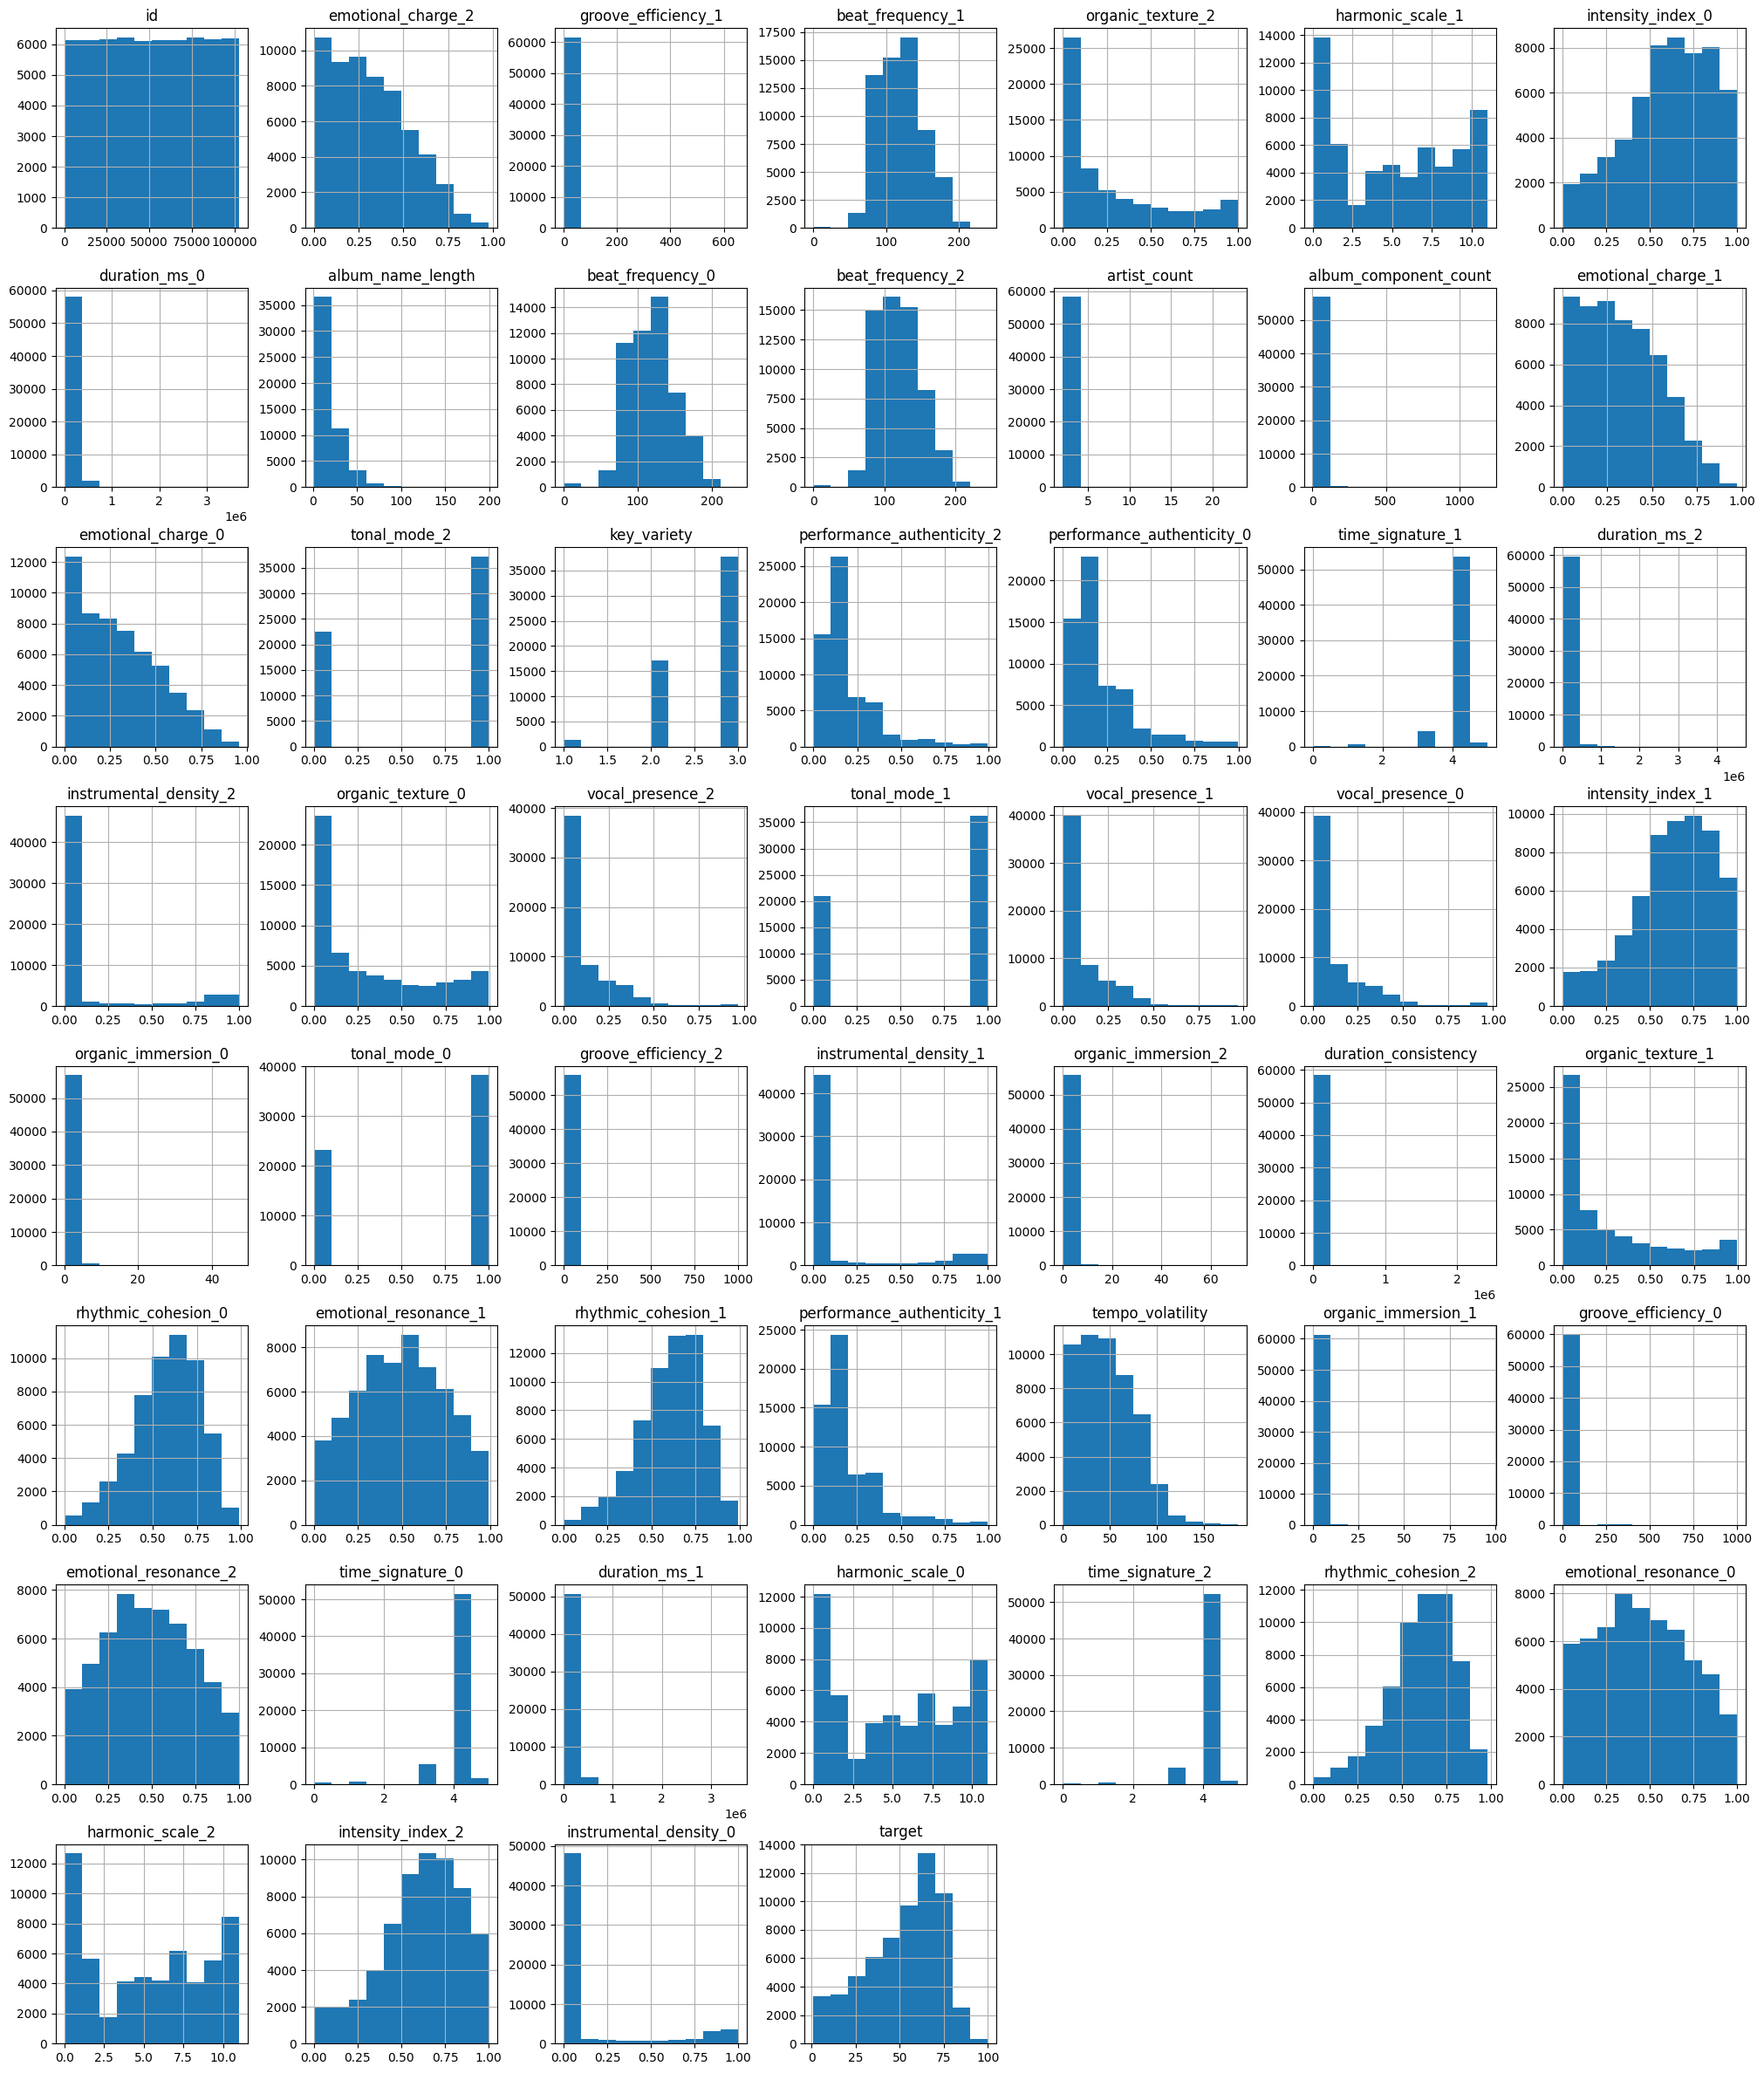

In [21]:
train_data[num_cols].hist(figsize=(25,30))

In [23]:
train_data.corr(numeric_only = True)['target'].sort_values(ascending = False)

,target
target,1.000000
intensity_index_1,0.133730
intensity_index_2,0.105045
rhythmic_cohesion_2,0.098248
rhythmic_cohesion_1,0.095772
emotional_charge_1,0.091120
intensity_index_0,0.081533
emotional_charge_2,0.062849
tempo_volatility,0.061882
album_component_count,0.052472


<Axes: >

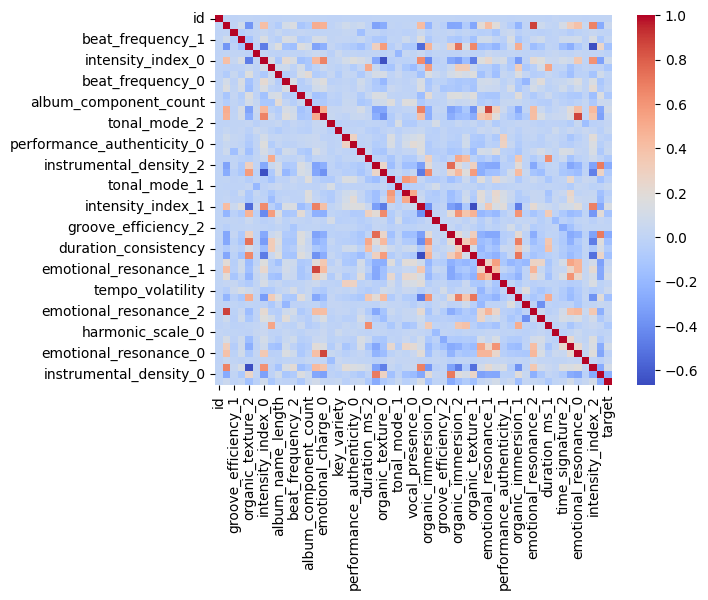

In [24]:
sns.heatmap(train_data[num_cols].corr(),cmap = "coolwarm")

<Axes: xlabel='emotional_charge_2', ylabel='target'>

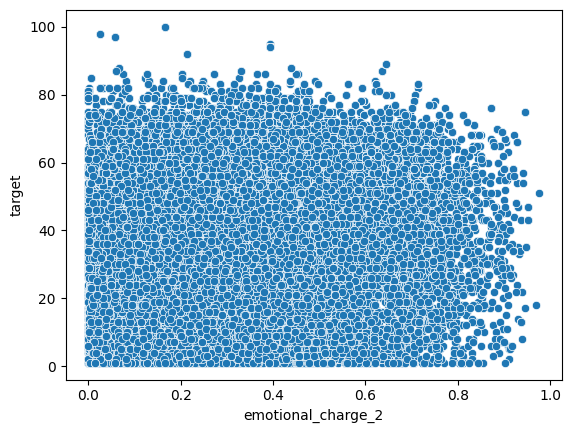

In [ ]:
sns.scatterplot(x=train_data['emotional_charge_2'],y = train_data['target'])